In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #for visualization


In [9]:
df = pd.read_csv("ecommerce")

In [ ]:
##EDA##

In [10]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [12]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [17]:
df.shape[0] #no of rows

500

In [16]:
df.shape[1] #no of columns

8

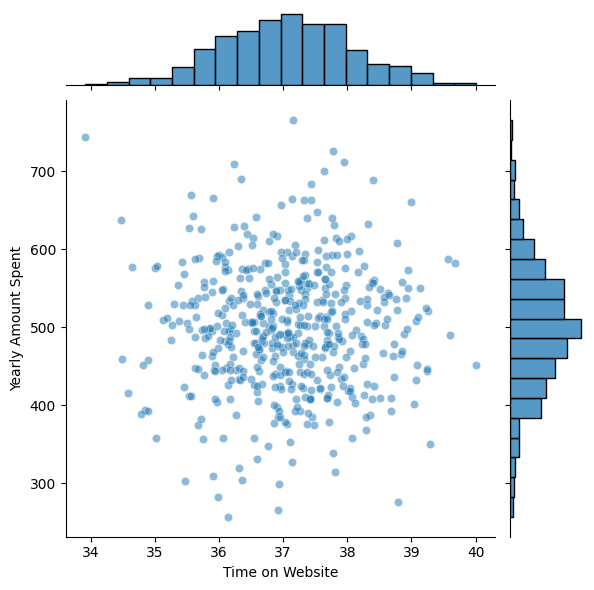

In [19]:
sns.jointplot(x="Time on Website", y="Yearly Amount Spent",data=df, alpha=0.5)

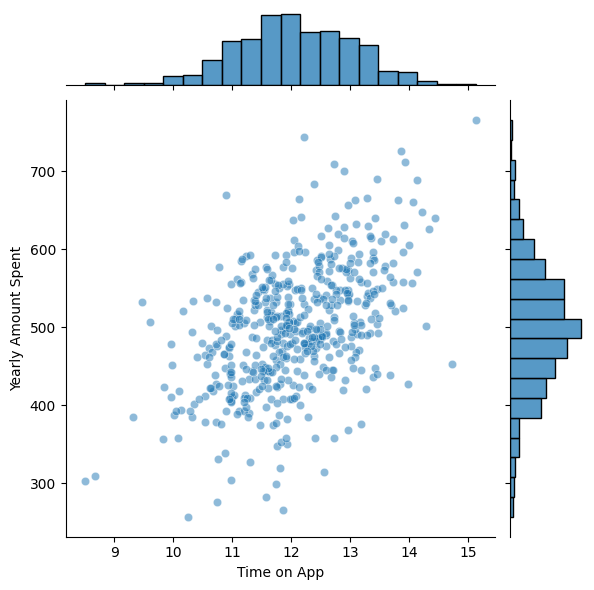

In [20]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent",data=df, alpha=0.5)

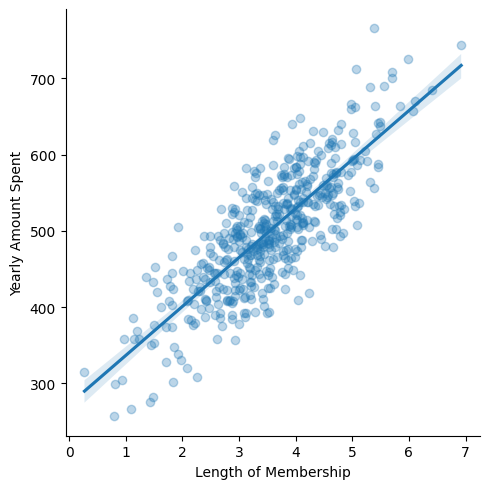

In [22]:
# length of membership vs yearly amount spent
sns.lmplot(x='Length of Membership', 
           y='Yearly Amount Spent', 
           data=df,
           scatter_kws={'alpha':0.3})

In [23]:
from sklearn.model_selection import train_test_split
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [24]:
X.head()
y.head()

0    587.951054
1    392.204933
2    487.547505
3    581.852344
4    599.406092
Name: Yearly Amount Spent, dtype: float64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
 lm.fit(X_train, y_train)

LinearRegression()

In [31]:
cdf = pd.DataFrame(lm.coef_,X.columns, columns=['coefficients']) #Tells us which variables are the most important
print(cdf)

                      coefficients
Avg. Session Length      25.596259
Time on App              38.785346
Time on Website           0.310386
Length of Membership     61.896829


In [33]:
#predictions

predictions = lm.predict(X_test)
predictions


array([402.86230051, 542.53325708, 426.62011918, 501.91386363,
       409.6666551 , 569.92155038, 531.50423529, 505.94309188,
       408.10378607, 473.45942928, 441.18668812, 424.52463471,
       424.83341694, 527.12061508, 430.87985533, 423.47062047,
       575.8751518 , 484.6563331 , 457.77896975, 481.58742311,
       501.56110993, 513.12815188, 507.49166899, 646.63377343,
       449.70050586, 496.26290484, 556.18523776, 554.78684161,
       399.1582784 , 325.16921284, 532.62732659, 477.73025415,
       500.76491535, 305.09971374, 505.46811902, 483.52069444,
       519.09464122, 437.75549737, 456.25005245, 470.63517876,
       494.11207805, 444.65549239, 508.57079732, 500.88197484,
       488.35128728, 535.34025218, 594.58301773, 513.59474408,
       279.69877702, 432.71590835, 421.06976164, 480.94327496,
       584.59481888, 608.61734059, 564.42312991, 494.47224504,
       393.95593318, 456.11321352, 572.92228417, 499.27385693,
       512.42973545, 391.56170305, 479.60705887, 481.05

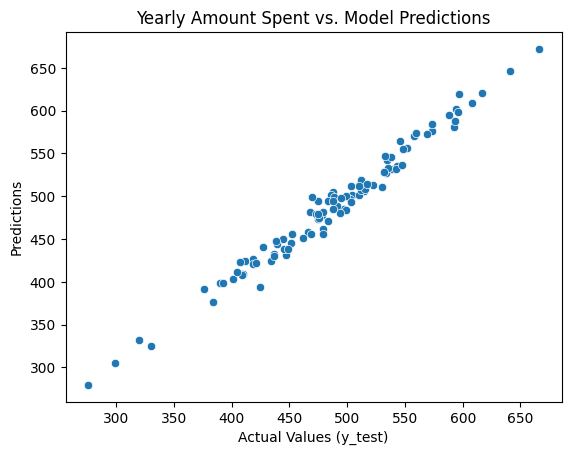

In [38]:
sns.scatterplot(x=y_test, y=predictions)
plt.ylabel('Predictions')
plt.xlabel('Actual Values (y_test)')
plt.title('Yearly Amount Spent vs. Model Predictions')
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
print('Mean Absolute Error:',mean_absolute_error(y_test, predictions))
print('Mean Squared Error:',mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error: 8.558441885315217
Mean Squared Error: 109.86374118393982
Root Mean Squared Error: 10.481590584636466


In [ ]:
#residuals
#residuals are the difference between the predictions and the actual value

In [41]:
res = predictions - y_test
res

361     1.829165
73      7.756069
374     8.017377
155    -2.064515
104    -0.402956
         ...    
347    -4.827772
86     -2.197933
75    -22.788656
438     5.685951
15    -10.072051
Name: Yearly Amount Spent, Length: 100, dtype: float64

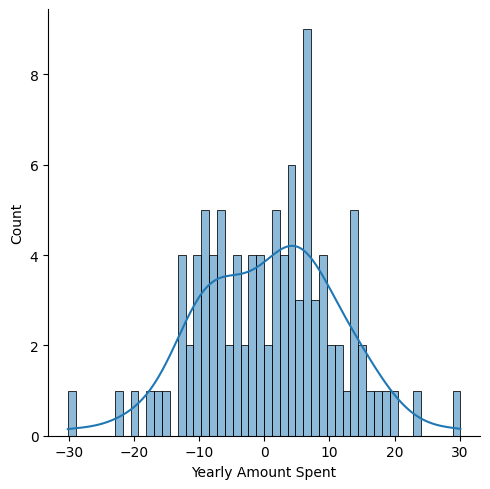

In [45]:
sns.displot(res, bins=50, kde=True)